# `05 — Binary search`

We study:
- **Binary search in a sorted array** (exists / find)
- **Left / right binary search**:
  - **lower_bound** (first index with x[i] >= key)
  - **upper_bound** (first index with x[i] > key)
- **Binary search on a function** (continuous)
- **Binary search by answer** (find minimum/maximum value that satisfies a monotone condition)

Goal:
- Know the **invariants** (this is what makes binary search correct)
- Know the **Big-O**: **O(log N)** iterations
- Be able to implement each variant correctly (no off-by-one bugs)

## `1. Core idea`

Binary search works when we have **monotonicity**.

Examples of monotonicity:
- In a sorted array, predicate **x[i] <= key** is monotone in i:
  it is **True True True ... False False**
- For a function, predicate **f(x) <= y0** can be monotone in x.
- For "search by answer", predicate **ok(T)** is monotone in T:
  **False False ... True True**

**Complexity:**
Each step halves the search interval → number of steps is **O(log N)**.

## `2. Binary search in a sorted array`

### `2.1 Search range: [l, r):`

We represent the active search interval as:

**$[l, r)$**  (left inclusive, right exclusive)

Meaning:
- candidates indices are $l, l+1, ..., r-1$
- length is $r - l$

This makes boundary handling cleaner.

In [4]:
# Implementation from slides:
from typing import List


def binsearch_exists(x: List[int], *, key: int, verbose: bool = True) -> bool:
    """
    Returns True if key exists in sorted array x.
    Slide version uses range [l, r) and ends with checking x[l] == key.
    """
    l: int = 0
    r: int = len(x)

    if verbose:
        print(f"x={x}, key={key}")
        print(f"start: l={l}, r={r}  (range=[{l},{r}))")

    while r - l > 1:
        m: int = (l + r) // 2

        if verbose:
            print(f"    m={(l+r)//2}, x[m]={x[m]}")

        if x[m] <= key:
            l = m
        else:
            r = m

        if verbose:
            print(f"    -> l={l}, r={r}  (range=[{l},{r}))")

    ans: bool = (len(x) > 0 and x[l] == key)
    if verbose:
        print(f"end check: x[l]={x[l]} == key? -> {ans}")
    return ans


print("-" * 55)
print(f"{'Binary search exists — Example 01':^55}")
print("-" * 55)
print(binsearch_exists([1, 2, 3, 4, 5, 7, 8], key=3, verbose=True))

print("-" * 55)
print(f"{'Binary search exists — Example 02 (not found)':^55}")
print("-" * 55)
print(binsearch_exists([1, 2, 3, 4, 5, 7, 8], key=6, verbose=True))


-------------------------------------------------------
           Binary search exists — Example 01           
-------------------------------------------------------
x=[1, 2, 3, 4, 5, 7, 8], key=3
start: l=0, r=7  (range=[0,7))
    m=3, x[m]=4
    -> l=0, r=3  (range=[0,3))
    m=1, x[m]=2
    -> l=1, r=3  (range=[1,3))
    m=2, x[m]=3
    -> l=2, r=3  (range=[2,3))
end check: x[l]=3 == key? -> True
True
-------------------------------------------------------
     Binary search exists — Example 02 (not found)     
-------------------------------------------------------
x=[1, 2, 3, 4, 5, 7, 8], key=6
start: l=0, r=7  (range=[0,7))
    m=3, x[m]=4
    -> l=3, r=7  (range=[3,7))
    m=5, x[m]=7
    -> l=3, r=5  (range=[3,5))
    m=4, x[m]=5
    -> l=4, r=5  (range=[4,5))
end check: x[l]=5 == key? -> False
False


## `3. Left / Right binary search (lower_bound / upper_bound)`

## `3.1 Idea`

For a sorted array x and a key:

- **lower_bound(key)** = first index `r` such that **x[r] >= key**
- **upper_bound(key)** = first index `r` such that **x[r] > key**

These are also called:
- left boundary / right boundary;
- L/R binary search.

If key appears multiple times:
- occurrences are in indices: [lower_bound(key), upper_bound(key));
- count = upper_bound - lower_bound.


In [7]:
from typing import List


def lower_bound(x: List[int], *, key: int, verbose: bool = True) -> int:
    """
    Returns first index r such that x[r] >= key.
    Slide: l=-1, r=len(x), move r when x[m] >= key.
    """
    l: int = -1
    r: int = len(x)

    if verbose:
        print(f"x={x}, key={key}")
        print(f"start: l={l}, r={r}  (invariant: x[l] < key, x[r] >= key)")

    while r - l > 1:
        m: int = (l + r) // 2
        if verbose:
            print(f"  m={m}, x[m]={x[m]}")

        if x[m] < key:
            l = m
        else:
            r = m

        if verbose:
            print(f"  -> l={l}, r={r}")

    if verbose:
        print(f"answer r={r}")
    return r


def upper_bound(x: List[int], *, key: int, verbose: bool = True) -> int:
    """
    Returns first index r such that x[r] > key.
    Slide: l=-1, r=len(x), move r when x[m] > key.
    """
    l: int = -1
    r: int = len(x)

    if verbose:
        print(f"x={x}, key={key}")
        print(f"start: l={l}, r={r}  (invariant: x[l] <= key, x[r] > key)")

    while r - l > 1:
        m: int = (l + r) // 2
        if verbose:
            print(f"   m={m}, x[m]={x[m]}")

        if x[m] <= key:
            l = m
        else:
            r = m

        if verbose:
            print(f"   -> l={l}, r={r}")

    if verbose:
        print(f"answer r={r}")
    return r


print("-" * 55)
print(f"{'Lower/Upper bound — Example 01 (duplicates)':^55}")
print("-" * 55)

arr = [1, 2, 3, 3, 3, 4, 8]
k = 3

lb = lower_bound(arr, key=k, verbose=True)
ub = upper_bound(arr, key=k, verbose=True)

print(f"\nlower_bound={lb}, upper_bound={ub}")
print(f"indices of {k}: [{lb}, {ub}) -> {arr[lb:ub]}")
print(f"count = {ub - lb}")


-------------------------------------------------------
      Lower/Upper bound — Example 01 (duplicates)      
-------------------------------------------------------
x=[1, 2, 3, 3, 3, 4, 8], key=3
start: l=-1, r=7  (invariant: x[l] < key, x[r] >= key)
  m=3, x[m]=3
  -> l=-1, r=3
  m=1, x[m]=2
  -> l=1, r=3
  m=2, x[m]=3
  -> l=1, r=2
answer r=2
x=[1, 2, 3, 3, 3, 4, 8], key=3
start: l=-1, r=7  (invariant: x[l] <= key, x[r] > key)
   m=3, x[m]=3
   -> l=3, r=7
   m=5, x[m]=4
   -> l=3, r=5
   m=4, x[m]=3
   -> l=4, r=5
answer r=5

lower_bound=2, upper_bound=5
indices of 3: [2, 5) -> [3, 3, 3]
count = 3


## `3.3 Python built-ins`

Python has these ready:
- `bisect_left(x, key)`  ≈ **lower_bound**
- `bisect_right(x, key)` ≈ **upper_bound**

In [8]:
from bisect import bisect_left, bisect_right

arr = [1, 2, 3, 3, 3, 4, 8]
k = 3
print("bisect_left :", bisect_left(arr, k))
print("bisect_right:", bisect_right(arr, k))

bisect_left : 2
bisect_right: 5


## `4. Binary search on a function (continuous)`

### `4.1 Binary search on a function`

We want to solve:
**f(x0) = y0**

Binary search works if:
- f(x) is **monotone** (increasing or decreasing)
- we know a range [l, r] where the solution lives

We turn it into a monotone boolean:
- check whether **$f(m) < y_0$** (or <= depending on definition)
- then shrink range

Stopping condition:
- stop when $ (r - l) <= \varepsilon $

Complexity:
- iterations ~ $O(\log(\frac{r - l}{\varepsilon}))$

In [9]:
from typing import Callable


def bsearch_real(
    f: Callable[[float], float],
    *,
    y0: float,
    l: float,
    r: float,
    eps: float = 1e-6,
    verbose: bool = True,
) -> float:
    """
    Finds x such that f(x) ~ y0 assuming f is increasing.
    """
    if verbose:
        print(f"target y0={y0}, start range=[{l}, {r}], eps={eps}")

    while r - l > eps:
        m: float = (l + r) / 2.0
        if verbose:
            print(f"  m={m:.6f}, f(m)={f(m):.6f}")

        if f(m) < y0:
            l = m
        else:
            r = m

    return (l + r) / 2.0


def sqrt_bsearch(x: float, *, eps: float = 1e-6, verbose: bool = True) -> float:
    r: float = max(1.0, float(x))
    return bsearch_real(lambda t: t * t, y0=x, l=0.0, r=r, eps=eps, verbose=verbose)


print("-" * 55)
print(f"{'Binary search on function — sqrt example':^55}")
print("-" * 55)

val = 10.0
approx = sqrt_bsearch(val, eps=1e-4, verbose=True)
print(f"\nsqrt({val}) ≈ {approx}  (check: {approx**2})")

-------------------------------------------------------
       Binary search on function — sqrt example        
-------------------------------------------------------
target y0=10.0, start range=[0.0, 10.0], eps=0.0001
  m=5.000000, f(m)=25.000000
  m=2.500000, f(m)=6.250000
  m=3.750000, f(m)=14.062500
  m=3.125000, f(m)=9.765625
  m=3.437500, f(m)=11.816406
  m=3.281250, f(m)=10.766602
  m=3.203125, f(m)=10.260010
  m=3.164062, f(m)=10.011292
  m=3.144531, f(m)=9.888077
  m=3.154297, f(m)=9.949589
  m=3.159180, f(m)=9.980416
  m=3.161621, f(m)=9.995848
  m=3.162842, f(m)=10.003568
  m=3.162231, f(m)=9.999708
  m=3.162537, f(m)=10.001638
  m=3.162384, f(m)=10.000673
  m=3.162308, f(m)=10.000190

sqrt(10.0) ≈ 3.1622695922851562  (check: 9.999948974291328)


## `5. Binary search by answer (find minimum T with ok (T)=True)`

## `5.1 Binary search by answer`

We want:
- **minimum** value T such that **ok(T) = True**

Requirements:

1) ok(T) is **monotone**:
   False False False ... True True True

2) we know a search range [l, r] where:
   - ok(l) = False
   - ok(r) = True

Binary search returns the boundary.


In [19]:
# Example 01: Binary search first True
from typing import Callable


def bsearch_first_true(
    ok: Callable[[int], bool],
    *,
    l: int,
    r: int,
    verbose: bool = True,
) -> int:
    """
    Find minimum integer T in (l, r] such that ok(T) is True,
    assuming ok is monotone and ok(l)=False, ok(r)=True.
    Returns r (the first True position).
    """
    if verbose:
        print('-' * 55)
        print(f"Start: l={l}, r={r}, ok(l)={ok(l)}, ok(r)={ok(r)}")

    while r - l > 1:
        m: int = (l + r) // 2

        if verbose:
            print(f"  m={m}, ok(m)={ok(m)}")

        if ok(m):
            r = m
        else:
            l = m

        if verbose:
            print(f"    -> l={l}, r={r}")

    if verbose:
        print(f"Answer: {r}")
        print('-' * 55)

    return r


In [24]:
# Example 01: Two copiers, times x and y seconds, need N copies, find minimum T such that number of copies ≥ N.
def min_time_xerox(*, n_copies: int, x: int, y: int, verbose: bool = True) -> int:
    """
    Slide idea:
    K(T) = T//x + T//y is monotone in T
    find minimal T such that K(T) >= N 
    """
    def ok(T: int) -> bool:
        return (T // x) + (T // y) >= n_copies

    # A safe upper bound from slides: r = N * min(x, y)
    l: int = -1
    r: int = n_copies * min(x, y)

    if verbose:
        print(f"Need N={n_copies} copies, copier times x={x}, y={y}")
        print(f"Search range: (l={l}, r={r}]  with ok(r)=True")

    ans = bsearch_first_true(ok, l=l, r=r, verbose=verbose)
    return ans


print("-" * 55)
print(f"{'Binary search by answer — Xerox example':^55}")
print("-" * 55)

print("Minimum time:", min_time_xerox(n_copies=10, x=2, y=3, verbose=True), "seconds")
print('-' * 55)

-------------------------------------------------------
        Binary search by answer — Xerox example        
-------------------------------------------------------
Need N=10 copies, copier times x=2, y=3
Search range: (l=-1, r=20]  with ok(r)=True
-------------------------------------------------------
Start: l=-1, r=20, ok(l)=False, ok(r)=True
  m=9, ok(m)=False
    -> l=9, r=20
  m=14, ok(m)=True
    -> l=9, r=14
  m=11, ok(m)=False
    -> l=11, r=14
  m=12, ok(m)=True
    -> l=11, r=12
Answer: 12
-------------------------------------------------------
Minimum time: 12 seconds
-------------------------------------------------------


# `6. Summary`

| Task | Condition | Result | Complexity |
|---|---|---|---|
| Exists in sorted array | sorted x | True/False | **O(log N)**|
| lower_bound | sorted x | first i with x[i] >= key | **O(log N)**|
| upper_bound | sorted x | first i with x[i] > key | **O(log N)**|
| function bsearch | monotone f | solve f(x)=y0 with eps | ~log((range)/eps)|
| bsearch by answer | monotone ok(T) | minimum T with ok(T)=True | **O(log range)**|


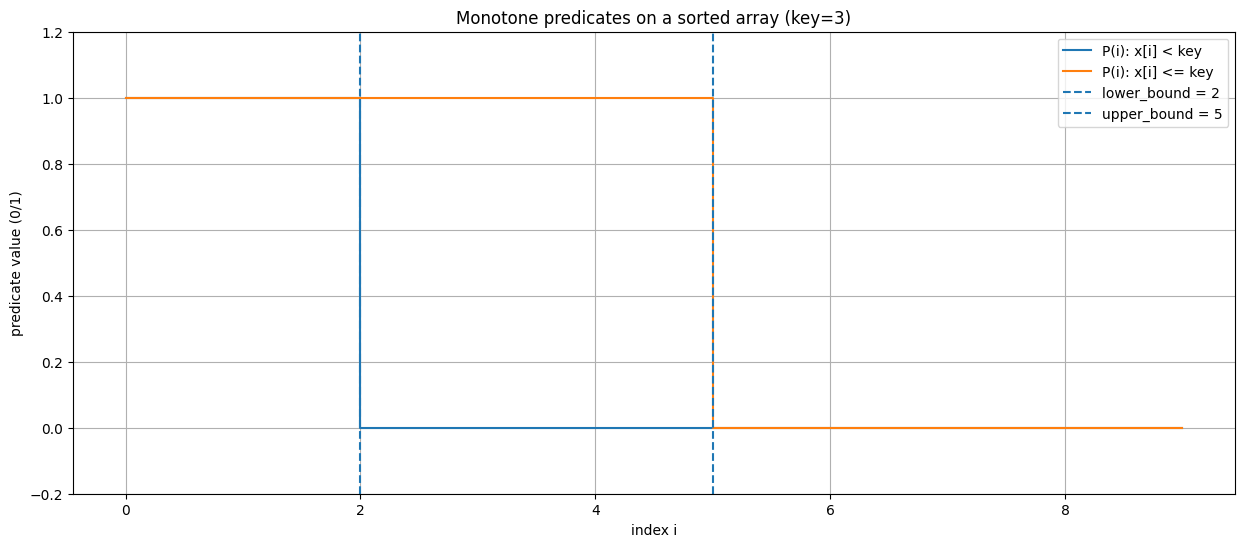

Array: [1, 2, 3, 3, 3, 4, 8, 10, 10, 11]
key=3
lower_bound=2  -> first index with x[i] >= key
upper_bound=5  -> first index with x[i] >  key
indices where x[i]==key: [2, 5) -> [3, 3, 3]


In [ ]:
import matplotlib.pyplot as plt
from typing import List

# This draws the predicate as a 0/1 staircase over indices, and marks lower_bound and upper_bound.

def lower_bound_simple(x: List[int], *, key: int) -> int:
    l: int = -1
    r: int = len(x)
    while r - l > 1:
        m: int = (l + r) // 2
        if x[m] < key:
            l = m
        else:
            r = m
    return r


def upper_bound_simple(x: List[int], *, key: int) -> int:
    l: int = -1
    r: int = len(x)
    while r - l > 1:
        m: int = (l + r) // 2
        if x[m] <= key:
            l = m
        else:
            r = m
    return r


def plot_step_predicates_sorted_array(x: List[int], *, key: int) -> None:
    """
    Visualizes the monotone predicates for binary search:
      P1(i) = (x[i] < key)    -> False...False then True...True  (depending on orientation)
      P2(i) = (x[i] <= key)

    We plot them as 0/1 over i, and show lb/ub boundaries.
    """
    n: int = len(x)
    idx: List[int] = list(range(n))

    p_lt: List[int] = [1 if x[i] < key else 0 for i in idx]
    p_le: List[int] = [1 if x[i] <= key else 0 for i in idx]

    lb: int = lower_bound_simple(x, key=key)
    ub: int = upper_bound_simple(x, key=key)

    plt.figure(figsize=(15, 6))
    plt.step(idx, p_lt, where="post", label="P(i): x[i] < key")
    plt.step(idx, p_le, where="post", label="P(i): x[i] <= key")
    plt.axvline(lb, linestyle="--", label=f"lower_bound = {lb}")
    plt.axvline(ub, linestyle="--", label=f"upper_bound = {ub}")
    plt.ylim(-0.2, 1.2)
    plt.xlabel("index i")
    plt.ylabel("predicate value (0/1)")
    plt.title(f"Monotone predicates on a sorted array (key={key})")
    plt.legend()
    plt.grid()
    plt.show()

    print("Array:", x)
    print(f"key={key}")
    print(f"lower_bound={lb}  -> first index with x[i] >= key")
    print(f"upper_bound={ub}  -> first index with x[i] >  key")
    print(f"indices where x[i]==key: [{lb}, {ub}) -> {x[lb:ub]}")


arr = [1, 2, 3, 3, 3, 4, 8, 10, 10, 11]
plot_step_predicates_sorted_array(arr, key=3)

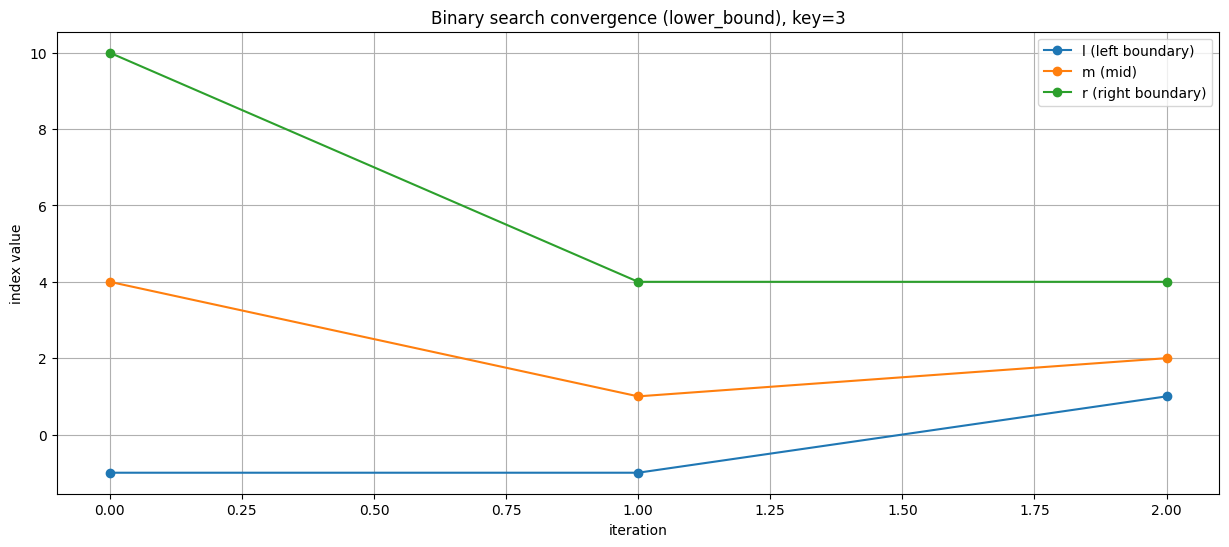

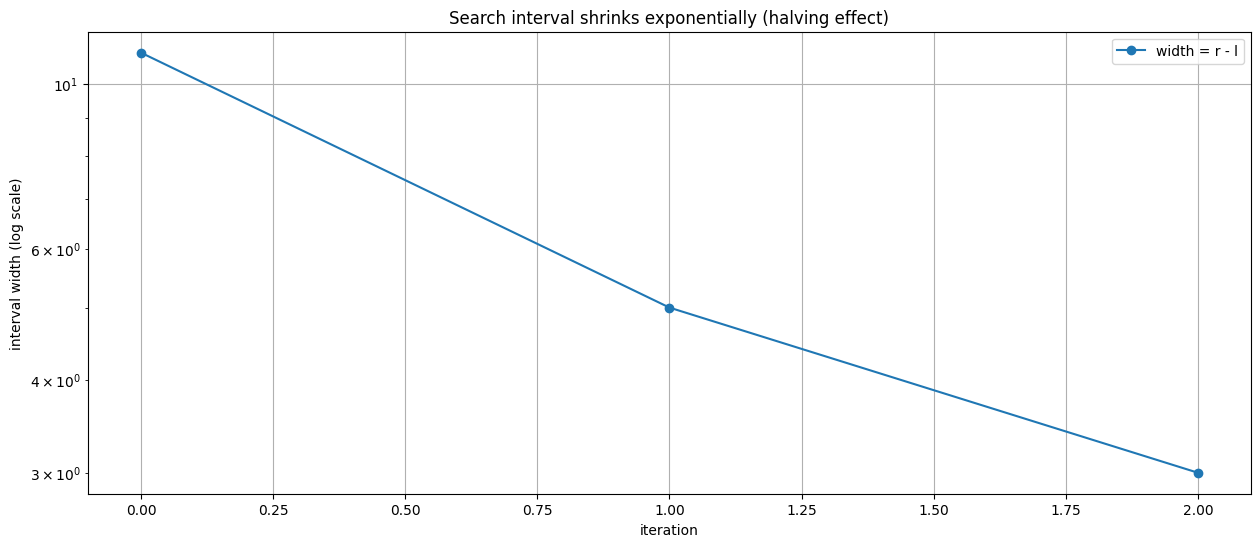

Array: [1, 2, 3, 3, 3, 4, 8, 10, 10, 11]
key=3
lower_bound answer = 2
Trace (l, m, r):
  iter= 0: l=-1, m= 4, r=10, x[m]=3
  iter= 1: l=-1, m= 1, r= 4, x[m]=2
  iter= 2: l= 1, m= 2, r= 4, x[m]=3


In [ ]:
import matplotlib.pyplot as plt
from typing import List, Tuple

# This one shows the actual movement of l, r, and m over iterations.

def lower_bound_trace(x: List[int], *, key: int) -> Tuple[int, List[Tuple[int, int, int]]]:
    """
    Returns:
      - answer r
      - list of (l, m, r) snapshots at each iteration
    Invariant:
      x[l] < key  (or l=-1)
      x[r] >= key (or r=n)
    """
    l: int = -1
    r: int = len(x)
    trace: List[Tuple[int, int, int]] = []

    while r - l > 1:
        m: int = (l + r) // 2
        trace.append((l, m, r))

        if x[m] < key:
            l = m
        else:
            r = m

    return r, trace


def plot_lr_convergence(x: List[int], *, key: int) -> None:
    ans, trace = lower_bound_trace(x, key=key)

    iters = list(range(len(trace)))
    ls = [t[0] for t in trace]
    ms = [t[1] for t in trace]
    rs = [t[2] for t in trace]
    widths = [r - l for l, _, r in trace]

    # Plot A: positions of l, m, r per iteration
    plt.figure(figsize=(15, 6))
    plt.plot(iters, ls, marker="o", label="l (left boundary)")
    plt.plot(iters, ms, marker="o", label="m (mid)")
    plt.plot(iters, rs, marker="o", label="r (right boundary)")
    plt.xlabel("iteration")
    plt.ylabel("index value")
    plt.title(f"Binary search convergence (lower_bound), key={key}")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot B: interval width shrinks roughly by half each step
    plt.figure(figsize=(15, 6))
    plt.plot(iters, widths, marker="o", label="width = r - l")
    plt.yscale("log")
    plt.xlabel("iteration")
    plt.ylabel("interval width (log scale)")
    plt.title("Search interval shrinks exponentially (halving effect)")
    plt.legend()
    plt.grid()
    plt.show()

    print("Array:", x)
    print(f"key={key}")
    print(f"lower_bound answer = {ans}")
    print("Trace (l, m, r):")
    for i, (l, m, r) in enumerate(trace):
        xm = x[m] if 0 <= m < len(x) else None
        print(f"  iter={i:>2}: l={l:>2}, m={m:>2}, r={r:>2}, x[m]={xm}")


arr = [1, 2, 3, 3, 3, 4, 8, 10, 10, 11]
plot_lr_convergence(arr, key=3)

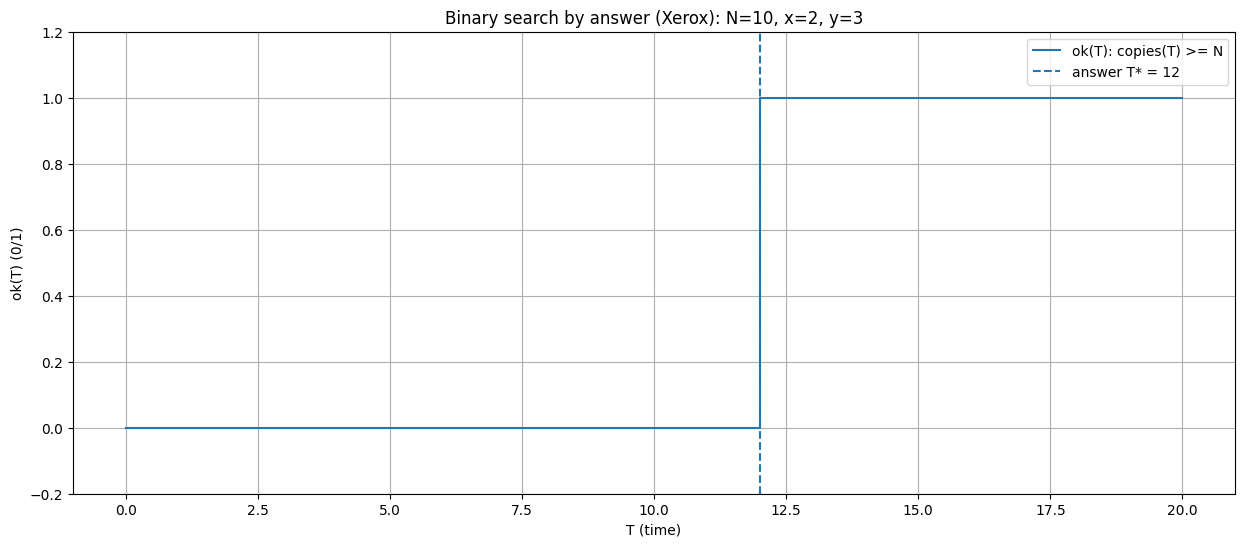

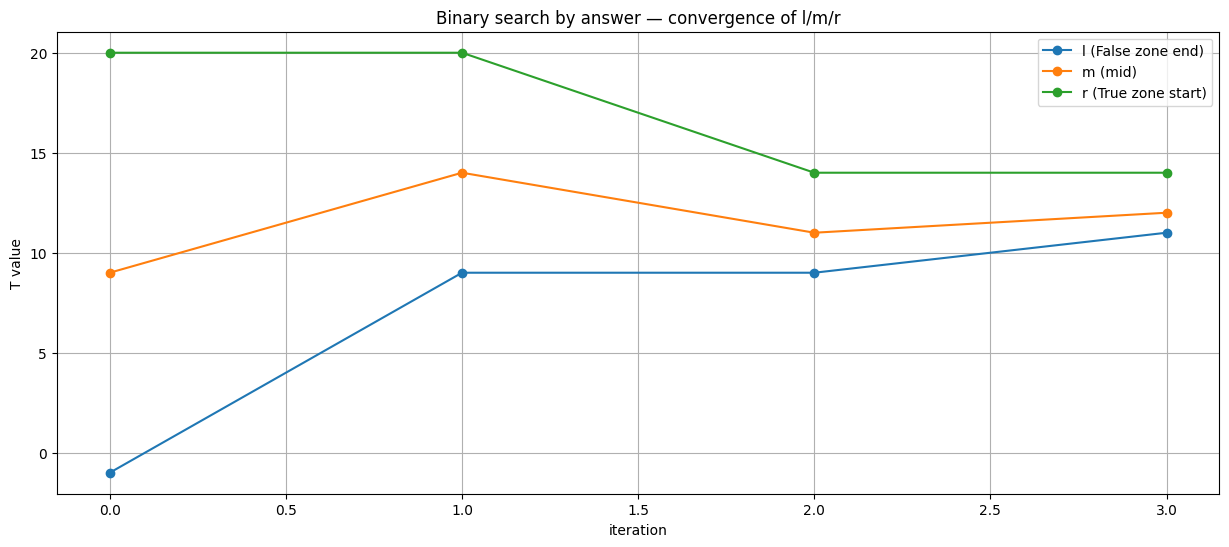

N=10, copier times: x=2, y=3
answer T*=12 seconds
copies(T*) = 10  (should be >= N)
copies(T*-1) = 8  (should be < N, if ans>0)
Trace (l, m, r, ok(m), copies(m)):
  iter= 0: l= -1, m=  9, r= 20, ok(m)=False, copies(m)=7
  iter= 1: l=  9, m= 14, r= 20, ok(m)=True, copies(m)=11
  iter= 2: l=  9, m= 11, r= 14, ok(m)=False, copies(m)=8
  iter= 3: l= 11, m= 12, r= 14, ok(m)=True, copies(m)=10


In [ ]:
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple

# This plots ok(T) as a step function over time and shows how binary search finds the first True.

def bsearch_first_true_trace(
    ok: Callable[[int], bool],
    *,
    l: int,
    r: int
) -> Tuple[int, List[Tuple[int, int, int]]]:
    """
    Find minimum T in (l, r] such that ok(T)=True,
    assuming ok is monotone and ok(l)=False, ok(r)=True.
    Returns (answer, trace of (l, m, r)).
    """
    trace: List[Tuple[int, int, int]] = []

    while r - l > 1:
        m: int = (l + r) // 2
        trace.append((l, m, r))
        if ok(m):
            r = m
        else:
            l = m

    return r, trace


def plot_binary_search_by_answer_xerox(*, n_copies: int, x: int, y: int) -> None:
    """
    Xerox model:
      copies(T) = T//x + T//y
    ok(T) := copies(T) >= n_copies  (monotone in T)
    """
    def copies(T: int) -> int:
        return (T // x) + (T // y)

    def ok(T: int) -> bool:
        return copies(T) >= n_copies

    l: int = -1
    r: int = n_copies * min(x, y)  # safe upper bound

    ans, trace = bsearch_first_true_trace(ok, l=l, r=r)

    # Plot A: ok(T) step function
    Ts: List[int] = list(range(0, r + 1))
    ok_vals: List[int] = [1 if ok(T) else 0 for T in Ts]

    plt.figure(figsize=(15, 6))
    plt.step(Ts, ok_vals, where="post", label="ok(T): copies(T) >= N")
    plt.axvline(ans, linestyle="--", label=f"answer T* = {ans}")
    plt.ylim(-0.2, 1.2)
    plt.xlabel("T (time)")
    plt.ylabel("ok(T) (0/1)")
    plt.title(f"Binary search by answer (Xerox): N={n_copies}, x={x}, y={y}")
    plt.legend()
    plt.grid()
    plt.show()

    # Plot B: convergence of l, m, r
    iters = list(range(len(trace)))
    ls = [t[0] for t in trace]
    ms = [t[1] for t in trace]
    rs = [t[2] for t in trace]

    plt.figure(figsize=(15, 6))
    plt.plot(iters, ls, marker="o", label="l (False zone end)")
    plt.plot(iters, ms, marker="o", label="m (mid)")
    plt.plot(iters, rs, marker="o", label="r (True zone start)")
    plt.xlabel("iteration")
    plt.ylabel("T value")
    plt.title("Binary search by answer — convergence of l/m/r")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"N={n_copies}, copier times: x={x}, y={y}")
    print(f"answer T*={ans} seconds")
    print(f"copies(T*) = {copies(ans)}  (should be >= N)")
    print(f"copies(T*-1) = {copies(ans-1)}  (should be < N, if ans>0)")
    print("Trace (l, m, r, ok(m), copies(m)):")
    for i, (ll, mm, rr) in enumerate(trace):
        print(f"  iter={i:>2}: l={ll:>3}, m={mm:>3}, r={rr:>3}, ok(m)={ok(mm)}, copies(m)={copies(mm)}")


plot_binary_search_by_answer_xerox(n_copies=10, x=2, y=3)